In [3]:
import pandas as pd

df = pd.read_csv("Food_Quality_Classification_Day15_Dataset.csv")

print(df.head())

   temperature  moisture  storage_days    ph quality_status
0         28.2      76.5            14  4.48    INVESTIGATE
1         20.2      28.8             2  4.48           PASS
2         26.0      35.3             1  4.92           PASS
3         24.6      42.2             6  4.47           PASS
4         13.3      29.4            26  5.28    INVESTIGATE


In [6]:
#2.Create X using the input features and y using the target variable. Explain what X represents and what y represents in this problem.
X = df[['temperature', 'moisture', 'storage_days', 'ph']]
y = df['quality_status']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [7]:
#3.Split the dataset into training and testing sets using train_test_split. State the test size you used and explain why the model should be evaluated on data that was not used for training.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


In [8]:
#4.Train a LogisticRegression model using the training data. Use the trained model to predict quality_status for the test data.
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# Predict quality_status for test data
y_pred = model.predict(X_test)

# Display predictions
print("Predicted quality_status:")
print(y_pred)

Predicted quality_status:
['PASS' 'PASS' 'PASS' 'INVESTIGATE' 'PASS' 'PASS' 'PASS' 'PASS'
 'INVESTIGATE' 'PASS' 'INVESTIGATE' 'PASS' 'INVESTIGATE' 'INVESTIGATE'
 'PASS' 'INVESTIGATE' 'PASS' 'PASS' 'INVESTIGATE' 'PASS' 'PASS' 'PASS'
 'PASS' 'INVESTIGATE' 'PASS' 'PASS' 'INVESTIGATE' 'PASS' 'PASS'
 'INVESTIGATE']


In [11]:
#5.from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate test-set metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

# Print results as percentages
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1-score:", round(f1 * 100, 2), "%")

Accuracy: 93.33 %
Precision: 94.67 %
Recall: 93.33 %
F1-score: 93.54 %


In [14]:
%pip install matplotlib


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.5 MB 11.2 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 13.5 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 10.5 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.5 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 9.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 8.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   --------------------- ------------------ 1.3/2.5 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 6.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------- ------------------------------- 1.6/7.2 MB 9.9 MB/s eta 0:00:01
   ------------- -------------------------- 2.4/7.2 MB 5.8 MB/s eta 0:00:01
   ----------------- --------------

Confusion Matrix:
[[20  2]
 [ 0  8]]


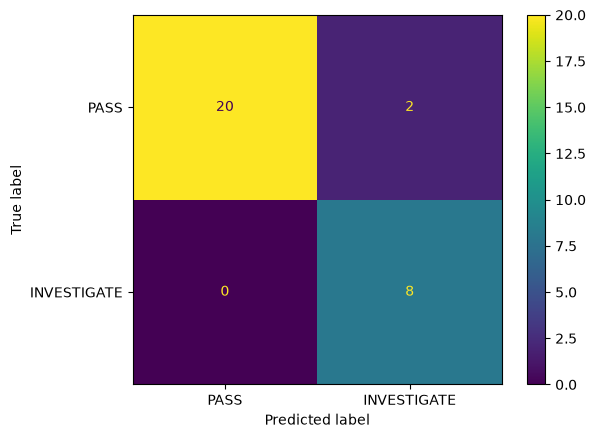

In [15]:
#6.Create a confusion matrix for the test predictions. Identify the true positives, true negatives, false positives, and false negatives. Explain what each type of result means in the food-quality context.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=['PASS', 'INVESTIGATE'])

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['PASS', 'INVESTIGATE']
)

disp.plot()
plt.show()